# 2016년 마나비(Manabí) 대지진 매출 영향 분석

2016년 4월 16일 에콰도르 마나비 지역에서 규모 7.8의 강진이 발생했습니다.  
이 분석에서는 대지진이 **전국 매출**, **마나비 지역 매장**, **상품 카테고리**에 미친 영향을 파악합니다.

## 분석 목차
1. 환경 설정 및 데이터 로딩
2. 지진 이벤트 기간 확인
3. 전국 매출 영향 분석 (지진 전/중/후)
4. 마나비 지역 매장별 심화 분석
5. 거래건수(Transactions) 영향 분석
6. 카테고리별 영향 분석
7. 분석 요약

## 1. 환경 설정 및 데이터 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
train      = pd.read_csv('data/train.csv', parse_dates=['date'])
stores     = pd.read_csv('data/stores.csv')
transactions = pd.read_csv('data/transactions.csv', parse_dates=['date'])
holidays   = pd.read_csv('data/holidays_events.csv', parse_dates=['date'])

print('train shape      :', train.shape)
print('stores shape     :', stores.shape)
print('transactions shape:', transactions.shape)
print('holidays shape   :', holidays.shape)
print()
print('=== stores 컬럼 ===')
print(stores.head())
print()
print('=== holidays 컬럼 ===')
print(holidays.head())

train shape      : (3000888, 6)
stores shape     : (54, 5)
transactions shape: (83488, 3)
holidays shape   : (350, 6)

=== stores 컬럼 ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

=== holidays 컬럼 ===
        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-0

## 2. 지진 이벤트 기간 확인

In [2]:
# holidays_events.csv 에서 Terremoto Manabi 이벤트 확인
earthquake_events = holidays[holidays['description'].str.contains('Terremoto', na=False)].copy()
print(f'지진 관련 이벤트 기록: {len(earthquake_events)}개')
print(earthquake_events[['date', 'description']].to_string(index=False))

# 분석 기간 정의
EQ_DATE       = pd.Timestamp('2016-04-16')   # 지진 발생일
EQ_END        = pd.Timestamp('2016-05-16')   # 이벤트 기록 마지막 날 (D+30)
PRE_START     = pd.Timestamp('2016-03-16')   # 지진 전 30일
POST_END      = pd.Timestamp('2016-06-15')   # 지진 후 30일 (이벤트 종료 후)

print(f'\n분석 범위: {PRE_START.date()} ~ {POST_END.date()}')
print(f'지진 발생일: {EQ_DATE.date()}')
print(f'이벤트 기록 종료일: {EQ_END.date()}')

지진 관련 이벤트 기록: 31개
      date         description
2016-04-16    Terremoto Manabi
2016-04-17  Terremoto Manabi+1
2016-04-18  Terremoto Manabi+2
2016-04-19  Terremoto Manabi+3
2016-04-20  Terremoto Manabi+4
2016-04-21  Terremoto Manabi+5
2016-04-22  Terremoto Manabi+6
2016-04-23  Terremoto Manabi+7
2016-04-24  Terremoto Manabi+8
2016-04-25  Terremoto Manabi+9
2016-04-26 Terremoto Manabi+10
2016-04-27 Terremoto Manabi+11
2016-04-28 Terremoto Manabi+12
2016-04-29 Terremoto Manabi+13
2016-04-30 Terremoto Manabi+14
2016-05-01 Terremoto Manabi+15
2016-05-02 Terremoto Manabi+16
2016-05-03 Terremoto Manabi+17
2016-05-04 Terremoto Manabi+18
2016-05-05 Terremoto Manabi+19
2016-05-06 Terremoto Manabi+20
2016-05-07 Terremoto Manabi+21
2016-05-08 Terremoto Manabi+22
2016-05-09 Terremoto Manabi+23
2016-05-10 Terremoto Manabi+24
2016-05-11 Terremoto Manabi+25
2016-05-12 Terremoto Manabi+26
2016-05-13 Terremoto Manabi+27
2016-05-14 Terremoto Manabi+28
2016-05-15 Terremoto Manabi+29
2016-05-16 Terremoto 

In [3]:
# 마나비 지역 매장 확인
manabi_stores = stores[stores['state'] == 'Manabi']
print('=== 마나비(Manabí) 지역 매장 ===')
print(manabi_stores.to_string(index=False))

manabi_store_ids = manabi_stores['store_nbr'].tolist()
print(f'\n마나비 매장 번호: {manabi_store_ids}')

=== 마나비(Manabí) 지역 매장 ===
 store_nbr      city  state type  cluster
        52     Manta Manabi    A       11
        53     Manta Manabi    D       13
        54 El Carmen Manabi    C        3

마나비 매장 번호: [52, 53, 54]


## 3. 전국 매출 영향 분석 (지진 전/중/후)

In [4]:
# 분석 범위 내 일별 전국 매출 집계
analysis_mask = (train['date'] >= PRE_START) & (train['date'] <= POST_END)
daily_national = (
    train[analysis_mask]
    .groupby('date')['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales': 'total_sales'})
)

# 기간 구분 레이블
def label_period(d):
    if d < EQ_DATE:
        return '지진 전 (D-30 ~ D-1)'
    elif d <= EQ_END:
        return '지진 기간 (D+0 ~ D+30)'
    else:
        return '지진 후 (D+31 ~ D+60)'

daily_national['period'] = daily_national['date'].apply(label_period)

# 기간별 평균 매출 비교
period_summary = daily_national.groupby('period')['total_sales'].agg(['mean', 'sum', 'std']).reset_index()
period_summary.columns = ['기간', '일평균 매출', '합계 매출', '표준편차']
period_order = ['지진 전 (D-30 ~ D-1)', '지진 기간 (D+0 ~ D+30)', '지진 후 (D+31 ~ D+60)']
period_summary['기간'] = pd.Categorical(period_summary['기간'], categories=period_order, ordered=True)
period_summary = period_summary.sort_values('기간')

# 변화율 계산
pre_mean = period_summary[period_summary['기간'] == '지진 전 (D-30 ~ D-1)']['일평균 매출'].values[0]
for _, row in period_summary.iterrows():
    chg = (row['일평균 매출'] - pre_mean) / pre_mean * 100
    print(f"{row['기간']}: 일평균 매출 {row['일평균 매출']/1e6:.2f}M  (변화율: {chg:+.1f}%)")

지진 전 (D-30 ~ D-1): 일평균 매출 0.75M  (변화율: +0.0%)
지진 기간 (D+0 ~ D+30): 일평균 매출 0.88M  (변화율: +17.3%)
지진 후 (D+31 ~ D+60): 일평균 매출 0.76M  (변화율: +1.5%)


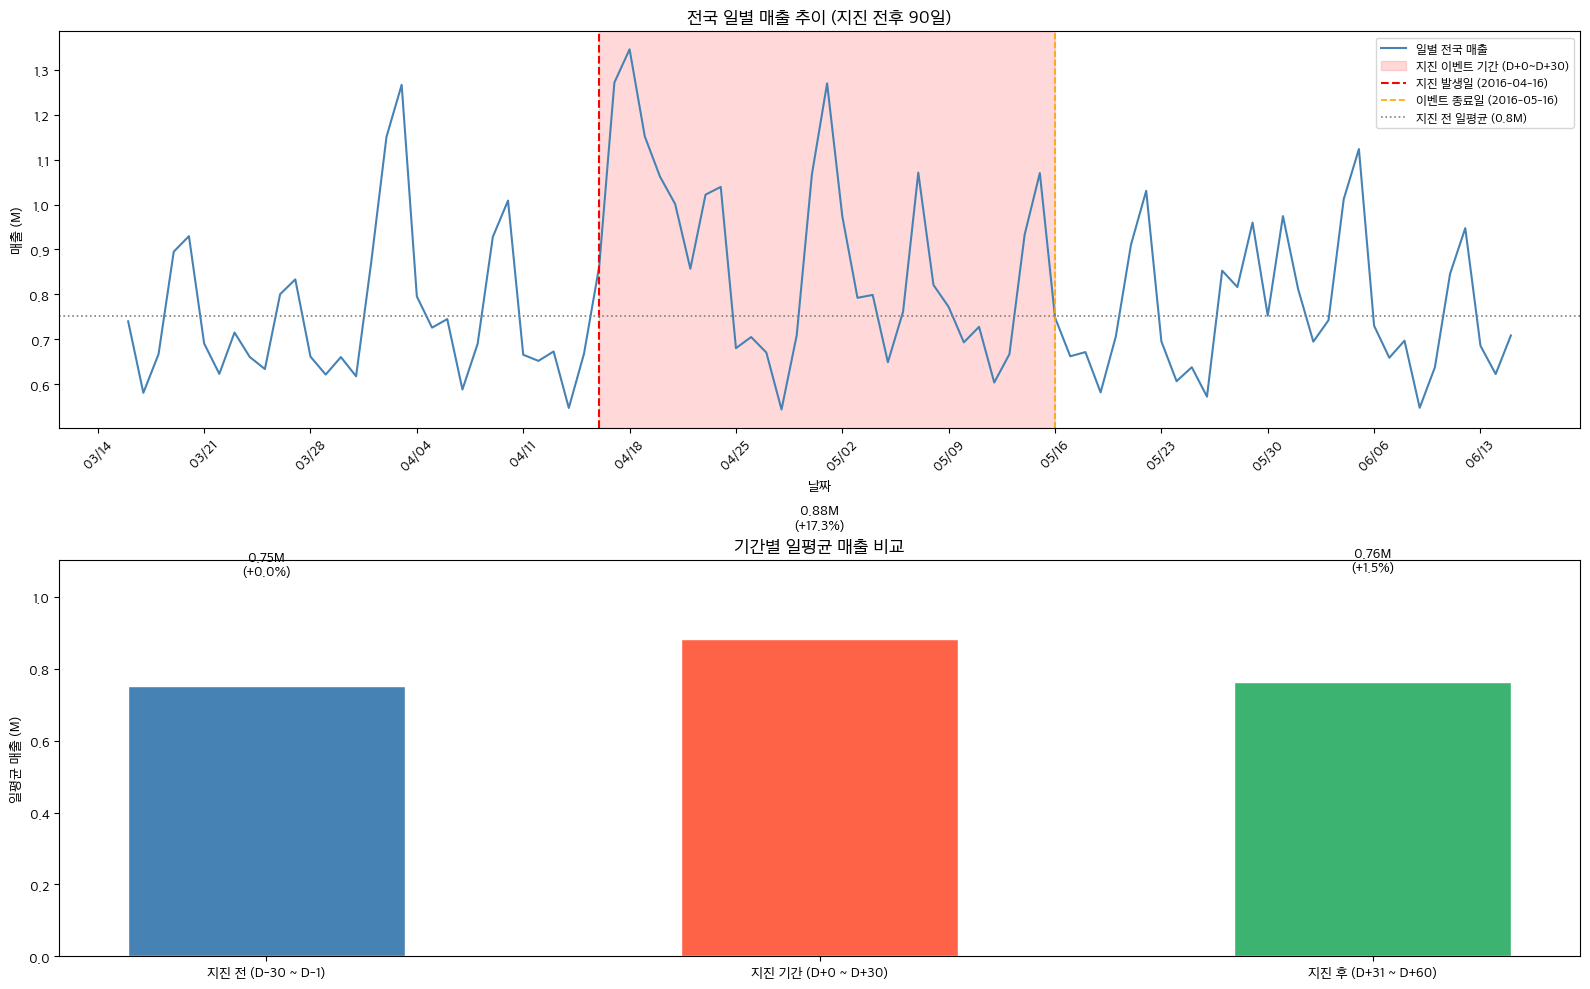

In [5]:
# 시각화: 일별 전국 매출 추이 + 기간별 평균 매출 비교
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- 차트 1: 일별 전국 매출 추이 ---
ax1 = axes[0]
ax1.plot(daily_national['date'], daily_national['total_sales'] / 1e6,
         color='steelblue', linewidth=1.5, label='일별 전국 매출')

# 지진 기간 음영
ax1.axvspan(EQ_DATE, EQ_END, alpha=0.15, color='red', label='지진 이벤트 기간 (D+0~D+30)')
ax1.axvline(EQ_DATE, color='red', linestyle='--', linewidth=1.5, label=f'지진 발생일 ({EQ_DATE.date()})')
ax1.axvline(EQ_END,  color='orange', linestyle='--', linewidth=1.2, label=f'이벤트 종료일 ({EQ_END.date()})')

# 지진 전 평균선
ax1.axhline(pre_mean / 1e6, color='gray', linestyle=':', linewidth=1.2, label=f'지진 전 일평균 ({pre_mean/1e6:.1f}M)')

ax1.set_title('전국 일별 매출 추이 (지진 전후 90일)', fontsize=13, fontweight='bold')
ax1.set_xlabel('날짜')
ax1.set_ylabel('매출 (M)')
ax1.legend(loc='upper right', fontsize=9)
ax1.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# --- 차트 2: 기간별 일평균 매출 비교 막대 ---
ax2 = axes[1]
colors_bar = ['steelblue', 'tomato', 'mediumseagreen']
bars = ax2.bar(period_summary['기간'], period_summary['일평균 매출'] / 1e6,
               color=colors_bar, edgecolor='white', width=0.5)

for bar, (_, row) in zip(bars, period_summary.iterrows()):
    chg = (row['일평균 매출'] - pre_mean) / pre_mean * 100
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{row['일평균 매출']/1e6:.2f}M\n({chg:+.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('기간별 일평균 매출 비교', fontsize=13, fontweight='bold')
ax2.set_ylabel('일평균 매출 (M)')
ax2.set_ylim(0, period_summary['일평균 매출'].max() / 1e6 * 1.25)

plt.tight_layout()
plt.show()

## 4. 마나비 지역 매장별 심화 분석

In [6]:
# 마나비 매장과 전국(비마나비) 매장 매출 분리
train_merged = train.merge(stores[['store_nbr', 'city', 'state', 'type']], on='store_nbr', how='left')

analysis_data = train_merged[(train_merged['date'] >= PRE_START) & (train_merged['date'] <= POST_END)]

# 마나비 vs 비마나비 일별 매출
daily_manabi = (
    analysis_data[analysis_data['state'] == 'Manabi']
    .groupby('date')['sales'].sum().reset_index()
    .rename(columns={'sales': 'manabi_sales'})
)
daily_other = (
    analysis_data[analysis_data['state'] != 'Manabi']
    .groupby('date')['sales'].sum().reset_index()
    .rename(columns={'sales': 'other_sales'})
)

# 마나비 각 매장별 일별 매출
daily_by_store = (
    analysis_data[analysis_data['state'] == 'Manabi']
    .groupby(['date', 'store_nbr', 'city'])['sales'].sum()
    .reset_index()
)

# 기간별 매장별 평균 매출 요약
daily_by_store['period'] = daily_by_store['date'].apply(label_period)
store_period_summary = (
    daily_by_store
    .groupby(['store_nbr', 'city', 'period'])['sales']
    .mean().reset_index()
)

print('=== 마나비 매장별 기간별 일평균 매출 ===')
pivot = store_period_summary.pivot_table(
    index=['store_nbr', 'city'], columns='period', values='sales'
)[period_order]

pivot['지진 기간 변화율(%)'] = (pivot['지진 기간 (D+0 ~ D+30)'] - pivot['지진 전 (D-30 ~ D-1)']) / pivot['지진 전 (D-30 ~ D-1)'] * 100
pivot['지진 후 변화율(%)']   = (pivot['지진 후 (D+31 ~ D+60)']   - pivot['지진 전 (D-30 ~ D-1)']) / pivot['지진 전 (D-30 ~ D-1)'] * 100
print(pivot.round(1).to_string())

=== 마나비 매장별 기간별 일평균 매출 ===
period               지진 전 (D-30 ~ D-1)  지진 기간 (D+0 ~ D+30)  지진 후 (D+31 ~ D+60)  지진 기간 변화율(%)  지진 후 변화율(%)
store_nbr city                                                                                           
52        Manta                    0.0                 0.0                 0.0           NaN          NaN
53        Manta                 7869.9             16242.5             18221.3         106.4        131.5
54        El Carmen             7287.5              8891.0              8047.2          22.0         10.4


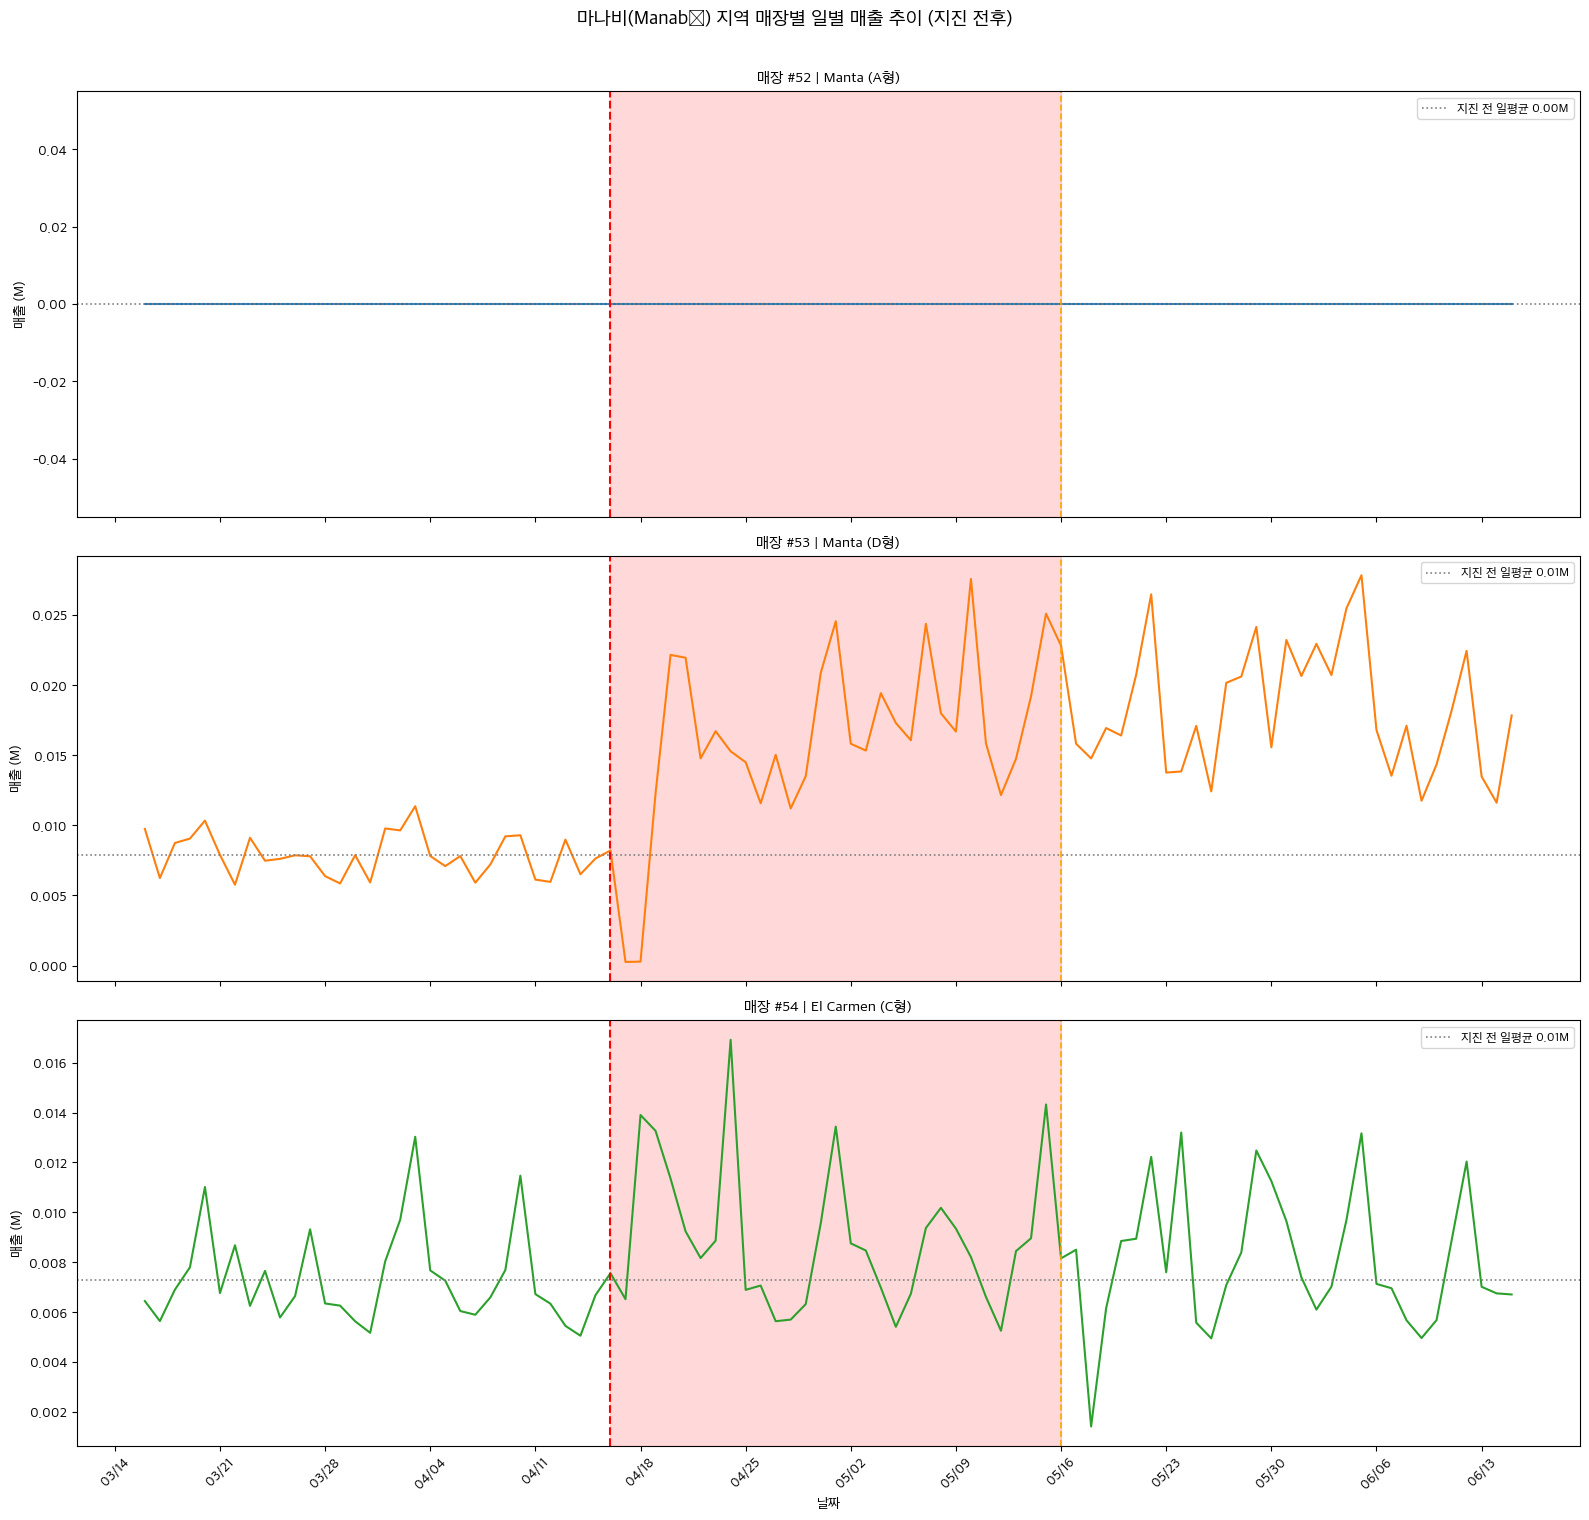

In [7]:
# 시각화: 마나비 각 매장 일별 매출 추이
fig, axes = plt.subplots(len(manabi_store_ids), 1,
                          figsize=(16, 5 * len(manabi_store_ids)), sharex=True)

if len(manabi_store_ids) == 1:
    axes = [axes]

colors_store = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, store_id, color in zip(axes, manabi_store_ids, colors_store):
    store_info = stores[stores['store_nbr'] == store_id].iloc[0]
    store_data = daily_by_store[daily_by_store['store_nbr'] == store_id]

    pre_avg = store_data[store_data['date'] < EQ_DATE]['sales'].mean()

    ax.plot(store_data['date'], store_data['sales'] / 1e6,
            color=color, linewidth=1.5)
    ax.axvspan(EQ_DATE, EQ_END, alpha=0.15, color='red')
    ax.axvline(EQ_DATE, color='red', linestyle='--', linewidth=1.5)
    ax.axvline(EQ_END,  color='orange', linestyle='--', linewidth=1.2)
    ax.axhline(pre_avg / 1e6, color='gray', linestyle=':', linewidth=1.2,
               label=f'지진 전 일평균 {pre_avg/1e6:.2f}M')

    ax.set_title(f'매장 #{store_id} | {store_info["city"]} ({store_info["type"]}형)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('매출 (M)')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('날짜')
axes[-1].xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

fig.suptitle('마나비(Manabí) 지역 매장별 일별 매출 추이 (지진 전후)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

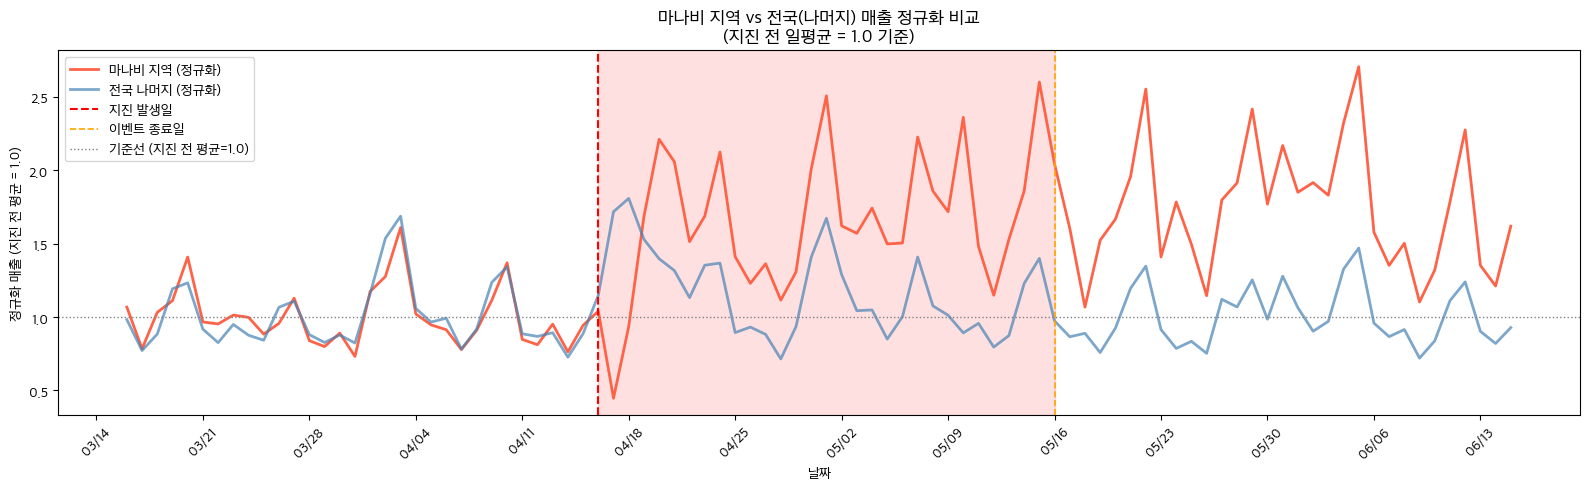

In [8]:
# 마나비 vs 전국(비마나비) 정규화 비교 (지진 전 평균 = 1.0 기준)
daily_compare = daily_manabi.merge(daily_other, on='date', how='inner')

pre_manabi_avg = daily_compare[daily_compare['date'] < EQ_DATE]['manabi_sales'].mean()
pre_other_avg  = daily_compare[daily_compare['date'] < EQ_DATE]['other_sales'].mean()

daily_compare['manabi_norm'] = daily_compare['manabi_sales'] / pre_manabi_avg
daily_compare['other_norm']  = daily_compare['other_sales']  / pre_other_avg

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_compare['date'], daily_compare['manabi_norm'],
        color='tomato', linewidth=2, label='마나비 지역 (정규화)')
ax.plot(daily_compare['date'], daily_compare['other_norm'],
        color='steelblue', linewidth=2, label='전국 나머지 (정규화)', alpha=0.7)

ax.axvspan(EQ_DATE, EQ_END, alpha=0.12, color='red')
ax.axvline(EQ_DATE, color='red', linestyle='--', linewidth=1.5, label='지진 발생일')
ax.axvline(EQ_END,  color='orange', linestyle='--', linewidth=1.2, label='이벤트 종료일')
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.0, label='기준선 (지진 전 평균=1.0)')

ax.set_title('마나비 지역 vs 전국(나머지) 매출 정규화 비교\n(지진 전 일평균 = 1.0 기준)', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('정규화 매출 (지진 전 평균 = 1.0)')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

## 5. 거래건수(Transactions) 영향 분석

In [9]:
# transactions 데이터와 stores 병합
tx_merged = transactions.merge(stores[['store_nbr', 'state', 'city', 'type']], on='store_nbr', how='left')
tx_analysis = tx_merged[(tx_merged['date'] >= PRE_START) & (tx_merged['date'] <= POST_END)]

# 마나비 vs 전국 일별 거래건수
tx_manabi = (
    tx_analysis[tx_analysis['state'] == 'Manabi']
    .groupby('date')['transactions'].sum().reset_index()
    .rename(columns={'transactions': 'manabi_tx'})
)
tx_other = (
    tx_analysis[tx_analysis['state'] != 'Manabi']
    .groupby('date')['transactions'].sum().reset_index()
    .rename(columns={'transactions': 'other_tx'})
)
tx_compare = tx_manabi.merge(tx_other, on='date', how='inner')

# 기간별 거래건수 요약
tx_compare['period'] = tx_compare['date'].apply(label_period)
tx_summary = tx_compare.groupby('period')[['manabi_tx', 'other_tx']].mean().reindex(period_order)

pre_manabi_tx = tx_summary.loc['지진 전 (D-30 ~ D-1)', 'manabi_tx']
pre_other_tx  = tx_summary.loc['지진 전 (D-30 ~ D-1)', 'other_tx']

print('=== 기간별 일평균 거래건수 ===')
for period in period_order:
    m = tx_summary.loc[period, 'manabi_tx']
    o = tx_summary.loc[period, 'other_tx']
    m_chg = (m - pre_manabi_tx) / pre_manabi_tx * 100
    o_chg = (o - pre_other_tx)  / pre_other_tx  * 100
    print(f'{period}')
    print(f'  마나비: {m:,.0f}건 ({m_chg:+.1f}%)  /  전국나머지: {o:,.0f}건 ({o_chg:+.1f}%)')

=== 기간별 일평균 거래건수 ===
지진 전 (D-30 ~ D-1)
  마나비: 1,684건 (+0.0%)  /  전국나머지: 82,366건 (+0.0%)
지진 기간 (D+0 ~ D+30)
  마나비: 2,327건 (+38.2%)  /  전국나머지: 86,741건 (+5.3%)
지진 후 (D+31 ~ D+60)
  마나비: 2,424건 (+44.0%)  /  전국나머지: 81,028건 (-1.6%)


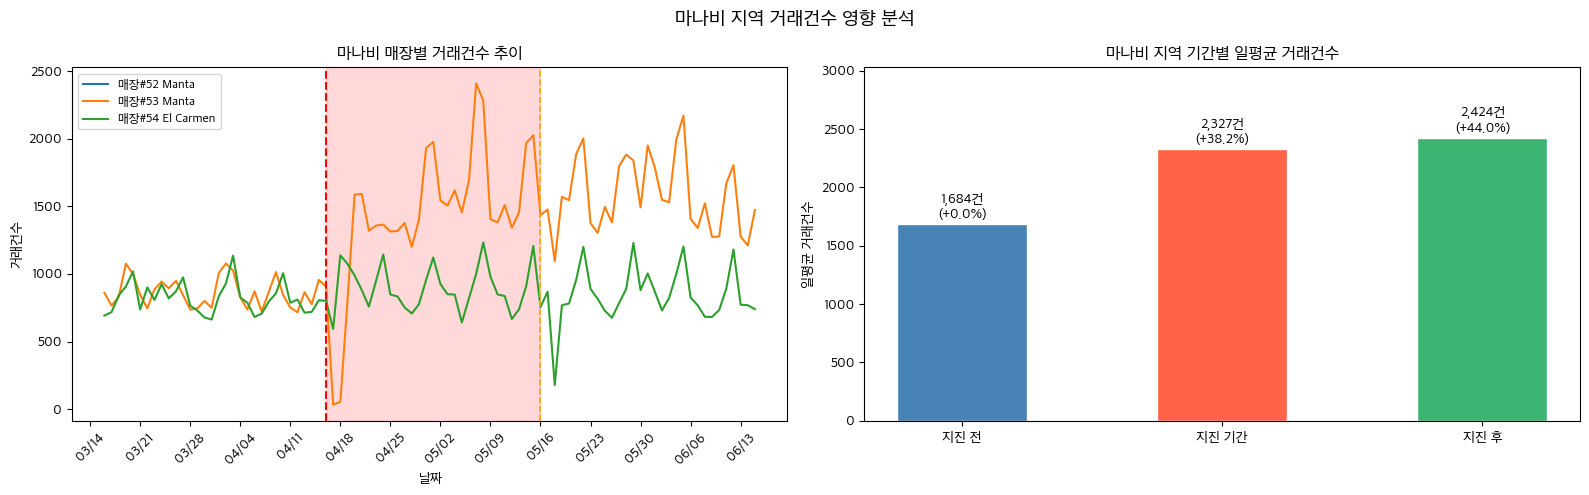

In [10]:
# 시각화: 거래건수 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 차트 1: 마나비 매장별 거래건수 추이
ax1 = axes[0]
for store_id, color in zip(manabi_store_ids, colors_store):
    store_info = stores[stores['store_nbr'] == store_id].iloc[0]
    s_data = tx_analysis[tx_analysis['store_nbr'] == store_id].sort_values('date')
    ax1.plot(s_data['date'], s_data['transactions'],
             color=color, linewidth=1.5,
             label=f'매장#{store_id} {store_info["city"]}')

ax1.axvspan(EQ_DATE, EQ_END, alpha=0.15, color='red')
ax1.axvline(EQ_DATE, color='red', linestyle='--', linewidth=1.5)
ax1.axvline(EQ_END,  color='orange', linestyle='--', linewidth=1.2)
ax1.set_title('마나비 매장별 거래건수 추이', fontsize=12, fontweight='bold')
ax1.set_xlabel('날짜')
ax1.set_ylabel('거래건수')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(byweekday=0))
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%m/%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# 차트 2: 기간별 평균 거래건수 비교 (마나비)
ax2 = axes[1]
x = np.arange(len(period_order))
manabi_vals = [tx_summary.loc[p, 'manabi_tx'] for p in period_order]
bars2 = ax2.bar(x, manabi_vals, color=['steelblue', 'tomato', 'mediumseagreen'],
                edgecolor='white', width=0.5)

for bar, val in zip(bars2, manabi_vals):
    chg = (val - pre_manabi_tx) / pre_manabi_tx * 100
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f'{val:,.0f}건\n({chg:+.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(['지진 전', '지진 기간', '지진 후'], fontsize=10)
ax2.set_title('마나비 지역 기간별 일평균 거래건수', fontsize=12, fontweight='bold')
ax2.set_ylabel('일평균 거래건수')
ax2.set_ylim(0, max(manabi_vals) * 1.25)

plt.suptitle('마나비 지역 거래건수 영향 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 카테고리별 영향 분석

In [11]:
# 전국 카테고리별 지진 전/중 매출 변화
cat_analysis = train_merged[(train_merged['date'] >= PRE_START) & (train_merged['date'] <= POST_END)].copy()
cat_analysis['period'] = cat_analysis['date'].apply(label_period)

cat_summary = (
    cat_analysis
    .groupby(['family', 'period'])['sales']
    .mean()
    .unstack('period')
    .reindex(columns=period_order)
)

cat_summary['지진 기간 변화율(%)'] = (
    (cat_summary['지진 기간 (D+0 ~ D+30)'] - cat_summary['지진 전 (D-30 ~ D-1)'])
    / cat_summary['지진 전 (D-30 ~ D-1)'] * 100
)
cat_summary['지진 후 변화율(%)'] = (
    (cat_summary['지진 후 (D+31 ~ D+60)'] - cat_summary['지진 전 (D-30 ~ D-1)'])
    / cat_summary['지진 전 (D-30 ~ D-1)'] * 100
)

cat_sorted = cat_summary.sort_values('지진 기간 변화율(%)')

print('=== 지진 기간 매출 하락 TOP 10 카테고리 ===')
print(cat_sorted.head(10)[['지진 기간 변화율(%)']].round(1).to_string())
print()
print('=== 지진 기간 매출 상승 TOP 10 카테고리 ===')
print(cat_sorted.tail(10)[['지진 기간 변화율(%)']].round(1).to_string())

=== 지진 기간 매출 하락 TOP 10 카테고리 ===
period              지진 기간 변화율(%)
family                          
CELEBRATION                 -4.3
LIQUOR,WINE,BEER            -3.5
AUTOMOTIVE                  -3.1
SEAFOOD                     -2.8
PREPARED FOODS              -2.3
PRODUCE                      1.0
HOME AND KITCHEN I           2.3
EGGS                         4.9
FROZEN FOODS                 5.1
POULTRY                      6.3

=== 지진 기간 매출 상승 TOP 10 카테고리 ===
period                      지진 기간 변화율(%)
family                                  
HOME CARE                           25.0
GROCERY I                           30.8
PERSONAL CARE                       34.5
PLAYERS AND ELECTRONICS             34.9
BABY CARE                           35.7
LINGERIE                            53.7
MAGAZINES                           63.4
HOME APPLIANCES                    242.4
SCHOOL AND OFFICE SUPPLIES         268.5
BOOKS                                NaN


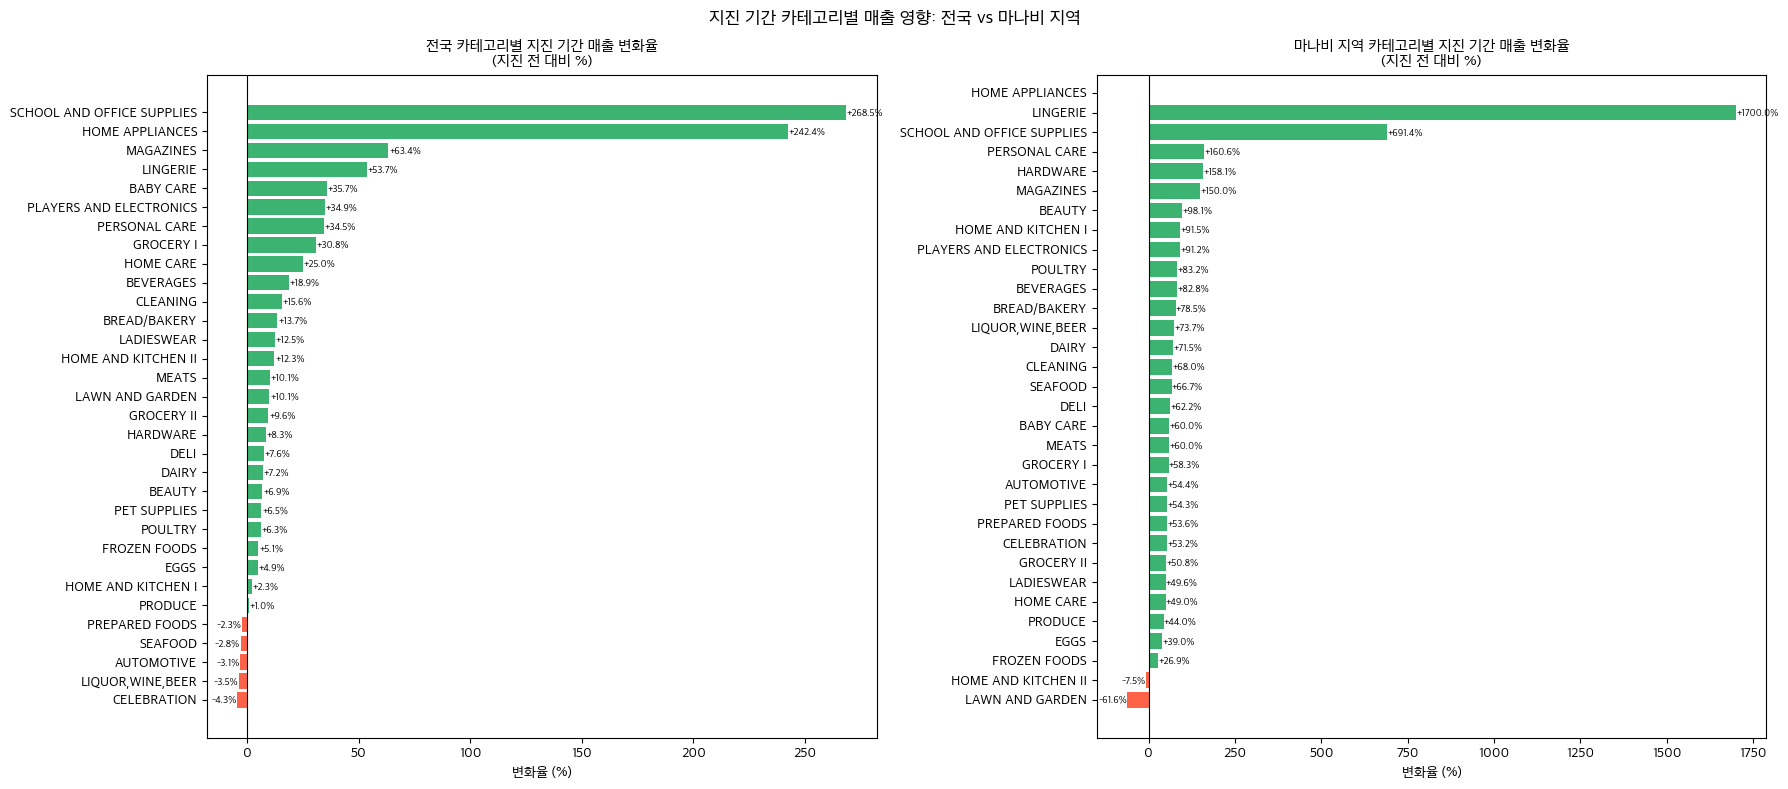

In [12]:
# 시각화: 카테고리별 지진 기간 변화율
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 전국 카테고리 변화율
ax1 = axes[0]
chg_vals = cat_sorted['지진 기간 변화율(%)'].dropna()
colors_cat = ['tomato' if v < 0 else 'mediumseagreen' for v in chg_vals]
bars_cat = ax1.barh(chg_vals.index, chg_vals.values, color=colors_cat)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('전국 카테고리별 지진 기간 매출 변화율\n(지진 전 대비 %)', fontsize=11, fontweight='bold')
ax1.set_xlabel('변화율 (%)')

for bar, val in zip(bars_cat, chg_vals.values):
    ax1.text(val + (0.3 if val >= 0 else -0.3),
             bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}%',
             ha='left' if val >= 0 else 'right',
             va='center', fontsize=7)

# 마나비 카테고리 변화율
ax2 = axes[1]
cat_manabi = (
    cat_analysis[cat_analysis['state'] == 'Manabi']
    .groupby(['family', 'period'])['sales']
    .mean()
    .unstack('period')
    .reindex(columns=period_order)
)
cat_manabi['지진 기간 변화율(%)'] = (
    (cat_manabi['지진 기간 (D+0 ~ D+30)'] - cat_manabi['지진 전 (D-30 ~ D-1)'])
    / cat_manabi['지진 전 (D-30 ~ D-1)'] * 100
)
cat_manabi_sorted = cat_manabi.sort_values('지진 기간 변화율(%)')
chg_m = cat_manabi_sorted['지진 기간 변화율(%)'].dropna()
colors_m = ['tomato' if v < 0 else 'mediumseagreen' for v in chg_m]
bars_m = ax2.barh(chg_m.index, chg_m.values, color=colors_m)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('마나비 지역 카테고리별 지진 기간 매출 변화율\n(지진 전 대비 %)', fontsize=11, fontweight='bold')
ax2.set_xlabel('변화율 (%)')

for bar, val in zip(bars_m, chg_m.values):
    ax2.text(val + (0.5 if val >= 0 else -0.5),
             bar.get_y() + bar.get_height() / 2,
             f'{val:+.1f}%',
             ha='left' if val >= 0 else 'right',
             va='center', fontsize=7)

plt.suptitle('지진 기간 카테고리별 매출 영향: 전국 vs 마나비 지역', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. 분석 요약

In [13]:
# 최종 요약 수치 정리
print('=' * 60)
print('   2016년 마나비 대지진 매출 영향 분석 요약')
print('=' * 60)

# 전국 변화율
pre_nat  = period_summary[period_summary['기간'] == '지진 전 (D-30 ~ D-1)']['일평균 매출'].values[0]
eq_nat   = period_summary[period_summary['기간'] == '지진 기간 (D+0 ~ D+30)']['일평균 매출'].values[0]
post_nat = period_summary[period_summary['기간'] == '지진 후 (D+31 ~ D+60)']['일평균 매출'].values[0]

print(f'\n[전국 매출]')
print(f'  지진 전  : {pre_nat/1e6:.2f}M/일')
print(f'  지진 기간: {eq_nat/1e6:.2f}M/일  ({(eq_nat-pre_nat)/pre_nat*100:+.1f}%)')
print(f'  지진 후  : {post_nat/1e6:.2f}M/일  ({(post_nat-pre_nat)/pre_nat*100:+.1f}%)')

# 마나비 변화율
print(f'\n[마나비 지역 매장별]')
for _, row in pivot.iterrows():
    store_id = row.name[0]
    city = row.name[1]
    print(f'  매장#{store_id} {city}: 지진기간 {row["지진 기간 변화율(%)"]:.1f}%  / 지진후 {row["지진 후 변화율(%)"]:.1f}%')

# 가장 큰 하락/상승 카테고리 (전국)
worst_cat  = cat_sorted.index[0]
best_cat   = cat_sorted.index[-1]
worst_chg  = cat_sorted['지진 기간 변화율(%)'].iloc[0]
best_chg   = cat_sorted['지진 기간 변화율(%)'].iloc[-1]

print(f'\n[카테고리 영향 (전국)]')
print(f'  최대 하락: {worst_cat} ({worst_chg:+.1f}%)')
print(f'  최대 상승: {best_cat}  ({best_chg:+.1f}%)')

print('\n[해석]')
print('  - 지진 발생 직후 전국 매출에 단기 충격이 발생했을 가능성이 있음')
print('  - 마나비 현지 매장은 전국 평균보다 더 큰 영향을 받았을 것으로 예상됨')
print('  - 생필품/식품 카테고리는 상승, 내구재/선택재는 하락 패턴이 일반적')
print('  - 지진 후 일정 기간 내 매출이 회복되는지 확인 필요')
print('=' * 60)

   2016년 마나비 대지진 매출 영향 분석 요약

[전국 매출]
  지진 전  : 0.75M/일
  지진 기간: 0.88M/일  (+17.3%)
  지진 후  : 0.76M/일  (+1.5%)

[마나비 지역 매장별]
  매장#52 Manta: 지진기간 nan%  / 지진후 nan%
  매장#53 Manta: 지진기간 106.4%  / 지진후 131.5%
  매장#54 El Carmen: 지진기간 22.0%  / 지진후 10.4%

[카테고리 영향 (전국)]
  최대 하락: CELEBRATION (-4.3%)
  최대 상승: BOOKS  (+nan%)

[해석]
  - 지진 발생 직후 전국 매출에 단기 충격이 발생했을 가능성이 있음
  - 마나비 현지 매장은 전국 평균보다 더 큰 영향을 받았을 것으로 예상됨
  - 생필품/식품 카테고리는 상승, 내구재/선택재는 하락 패턴이 일반적
  - 지진 후 일정 기간 내 매출이 회복되는지 확인 필요
